<a href="https://colab.research.google.com/github/DEESHA-AFK/T076-ARTIFICIAL-INTELLIGENCE-PRACTICAL/blob/main/T076_DEESHA_CHAVAN_AI_PRAC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PART A: BFS RESULT
Path Discovered : Versova -> JP Rd/Versova Marg -> Anant Kanekar Marg/Station Rd -> Bandra Station (West)
Hops (edges)    : 3
Total Distance  : 13.35 km
Nodes Expanded  : 5
Max Frontier    : 3
Time Taken      : 0.0677 ms

PART B: ITERATIVE DEEPENING DFS (ID-DFS) RESULT
Path Discovered  : Versova -> JP Rd/Versova Marg -> Anant Kanekar Marg/Station Rd -> Bandra Station (West)
Hops (edges)     : 3
Total Distance   : 13.35 km
Nodes Expanded   : 11  (includes re-expansion across depth iterations)
Depth Reached    : 3
Time Taken       : 0.0554 ms

PART C: PERFORMANCE & EFFICIENCY COMPARISON
Metric                      BFS                      ID-DFS                   
------------------------------------------------------------------------------
Hops (edges)                3                        3                        
Total distance (km)         13.35                    13.35                    
Nodes expanded              5                        11                  

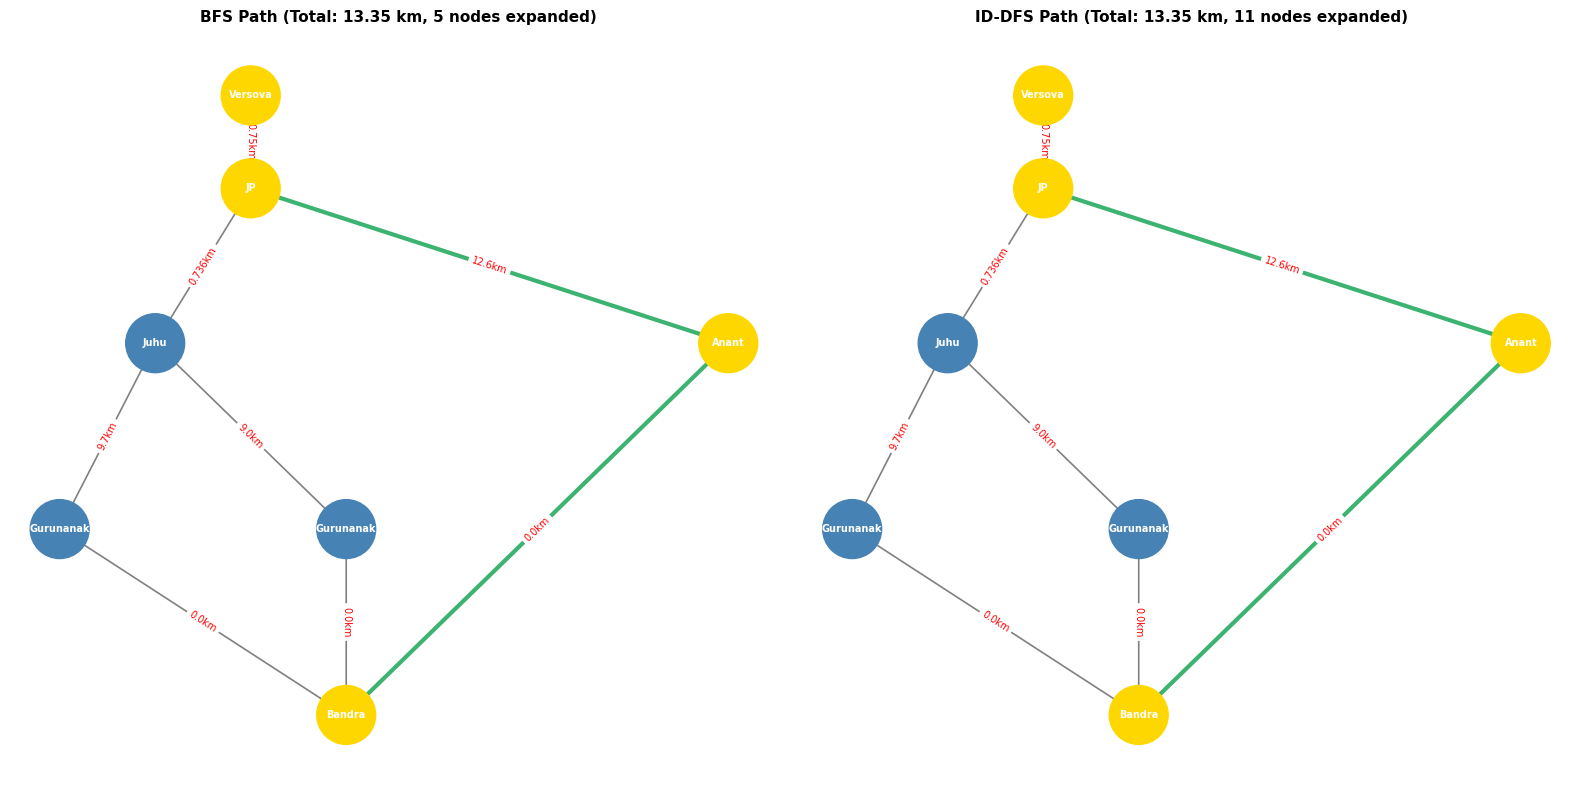

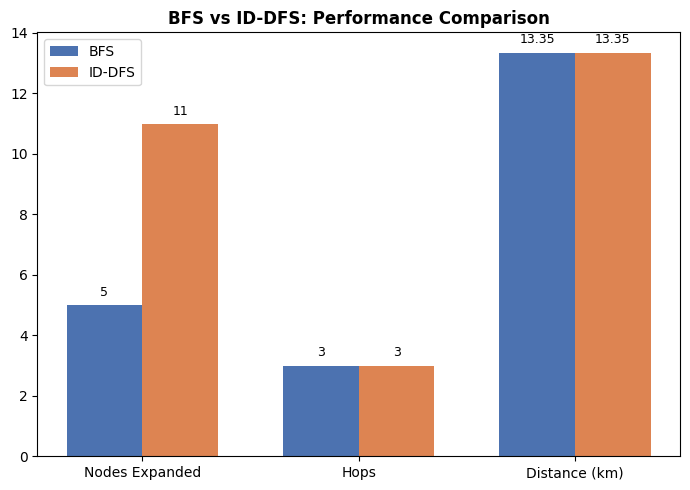

In [6]:
"""
Breadth-First Search (BFS) and Iterative Deepening DFS (ID-DFS) in AI
Solving the same pathfinding problem as the A*/RBFS practicals: Versova -> Bandra Station (West).

Part A: BFS
Part B: Iterative Deepening DFS (IDDFS)
Part C: Performance & efficiency comparison
"""

import time
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx

# -------------------------------------------------------------------------
# 1. DATA STRUCTURE POPULATION  (same real-route graph used for A* / RBFS)
# -------------------------------------------------------------------------

# Actual Road Distance (in km) between interconnected nodes
# Built from 3 real Google Maps routes: Versova -> Bandra Station (West)
#   Route 1 (13.3 km, 43 min): via NH 48 / Anant Kanekar Marg
#   Route 2 (11.2 km, 47 min): via Juhu Tara Rd
#   Route 3 (10.5 km, 47 min): via Swami Vivekanand Rd
graph = {
    'Versova':                                     {'JP Rd/Versova Marg': 0.75},
    'JP Rd/Versova Marg':                           {'Anant Kanekar Marg/Station Rd': 12.6,
                                                       'Juhu Versova Link Rd Jn': 0.736},
    'Juhu Versova Link Rd Jn':                        {'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)': 9.7,
                                                         'Gurunanak Rd/Turner Rd (via SV Road)': 9.0},
    'Anant Kanekar Marg/Station Rd':                   {'Bandra Station (West)': 0.0},
    'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)':          {'Bandra Station (West)': 0.0},
    'Gurunanak Rd/Turner Rd (via SV Road)':                {'Bandra Station (West)': 0.0},
    'Bandra Station (West)':                                {}
}

# Rough spatial coordinates (X, Y) for plotting -- same layout as the RBFS map
node_positions = {
    'Versova':                                     (1, 10),
    'JP Rd/Versova Marg':                            (1, 8.5),
    'Anant Kanekar Marg/Station Rd':                   (3.5, 6),
    'Juhu Versova Link Rd Jn':                          (0.5, 6),
    'Gurunanak Rd/Turner Rd (via Juhu Tara Rd)':           (0, 3),
    'Gurunanak Rd/Turner Rd (via SV Road)':                 (1.5, 3),
    'Bandra Station (West)':                                 (1.5, 0)
}

START, GOAL = 'Versova', 'Bandra Station (West)'


def path_cost(path):
    """Total real road distance (km) of a path through the weighted graph."""
    return round(sum(graph[a][b] for a, b in zip(path, path[1:])), 3)


# -------------------------------------------------------------------------
# PART A: BREADTH-FIRST SEARCH (BFS)
# -------------------------------------------------------------------------
# BFS explores level by level (fewest ROAD JUNCTIONS / hops), completely
# ignoring edge weights (actual km). It guarantees the path with the
# fewest edges, NOT the shortest distance.

def bfs_search(graph, start, goal):
    frontier = deque([[start]])
    visited = {start}
    nodes_expanded = 0
    max_frontier = 1

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        path = frontier.popleft()
        current = path[-1]
        nodes_expanded += 1

        if current == goal:
            return path, nodes_expanded, max_frontier

        for neighbor in graph[current]:
            if neighbor not in visited:
                visited.add(neighbor)
                frontier.append(path + [neighbor])

    return None, nodes_expanded, max_frontier


# -------------------------------------------------------------------------
# PART B: ITERATIVE DEEPENING DFS (ID-DFS)
# -------------------------------------------------------------------------
# Repeats a Depth-Limited DFS with depth_limit = 0, 1, 2, ... until the
# goal is found. Combines DFS's low memory footprint with BFS's
# completeness/optimality (in terms of edge count) on unweighted graphs.

def depth_limited_dfs(graph, current, goal, limit, path, stats):
    stats['nodes_expanded'] += 1
    if current == goal:
        return path
    if limit <= 0:
        return None
    for neighbor in graph[current]:
        if neighbor not in path:                      # avoid cycles
            result = depth_limited_dfs(graph, neighbor, goal, limit - 1,
                                        path + [neighbor], stats)
            if result is not None:
                return result
    return None


def iddfs_search(graph, start, goal, max_depth=10):
    total_nodes_expanded = 0
    for depth in range(max_depth + 1):
        stats = {'nodes_expanded': 0}
        result = depth_limited_dfs(graph, start, goal, depth, [start], stats)
        total_nodes_expanded += stats['nodes_expanded']
        if result is not None:
            return result, total_nodes_expanded, depth
    return None, total_nodes_expanded, max_depth


# -------------------------------------------------------------------------
# RUN BOTH ALGORITHMS
# -------------------------------------------------------------------------

t0 = time.perf_counter()
bfs_path, bfs_nodes_expanded, bfs_max_frontier = bfs_search(graph, START, GOAL)
t1 = time.perf_counter()
bfs_time_ms = (t1 - t0) * 1000

t0 = time.perf_counter()
iddfs_path, iddfs_nodes_expanded, iddfs_depth = iddfs_search(graph, START, GOAL)
t1 = time.perf_counter()
iddfs_time_ms = (t1 - t0) * 1000

print("=" * 70)
print("PART A: BFS RESULT")
print("=" * 70)
print(f"Path Discovered : {' -> '.join(bfs_path)}")
print(f"Hops (edges)    : {len(bfs_path) - 1}")
print(f"Total Distance  : {path_cost(bfs_path)} km")
print(f"Nodes Expanded  : {bfs_nodes_expanded}")
print(f"Max Frontier    : {bfs_max_frontier}")
print(f"Time Taken      : {bfs_time_ms:.4f} ms\n")

print("=" * 70)
print("PART B: ITERATIVE DEEPENING DFS (ID-DFS) RESULT")
print("=" * 70)
print(f"Path Discovered  : {' -> '.join(iddfs_path)}")
print(f"Hops (edges)     : {len(iddfs_path) - 1}")
print(f"Total Distance   : {path_cost(iddfs_path)} km")
print(f"Nodes Expanded   : {iddfs_nodes_expanded}  (includes re-expansion across depth iterations)")
print(f"Depth Reached    : {iddfs_depth}")
print(f"Time Taken       : {iddfs_time_ms:.4f} ms\n")

# -------------------------------------------------------------------------
# PART C: COMPARISON
# -------------------------------------------------------------------------

print("=" * 70)
print("PART C: PERFORMANCE & EFFICIENCY COMPARISON")
print("=" * 70)
header = f"{'Metric':<28}{'BFS':<25}{'ID-DFS':<25}"
print(header)
print("-" * len(header))
rows = [
    ("Hops (edges)",            str(len(bfs_path) - 1),           str(len(iddfs_path) - 1)),
    ("Total distance (km)",     str(path_cost(bfs_path)),         str(path_cost(iddfs_path))),
    ("Nodes expanded",          str(bfs_nodes_expanded),          str(iddfs_nodes_expanded)),
    ("Time taken (ms)",         f"{bfs_time_ms:.4f}",              f"{iddfs_time_ms:.4f}"),
    ("Space complexity",        "O(b^d) - full frontier kept",    "O(b*d) - only current path kept"),
    ("Optimal on unweighted?",  "Yes (fewest hops)",               "Yes (fewest hops)"),
    ("Optimal on real km?",     "No",                              "No"),
]
for metric, b, i in rows:
    print(f"{metric:<28}{b:<25}{i:<25}")

print("""
Observation:
Both BFS and ID-DFS are UNINFORMED (blind) search strategies -- neither uses
the road-distance weights or a heuristic. On this graph both land on the
SAME path (fewest road junctions), which happens to be the NH 48 route
(13.3 km) -- NOT the true shortest route (10.5 km via Swami Vivekanand Rd)
that A* / RBFS found earlier, since that route needs one extra hop.
This is the classic blind-search weakness: minimizing hop count is not the
same as minimizing actual distance/cost.
""")

# -------------------------------------------------------------------------
# 3. VISUALIZATION
# -------------------------------------------------------------------------

def draw_route_map(ax, path, title):
    G = nx.DiGraph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors.items():
            G.add_edge(node, neighbor, weight=weight)

    path_edges = list(zip(path, path[1:]))
    normal_edges = [edge for edge in G.edges() if edge not in path_edges]
    path_node_set = set(path)
    node_colors = ['gold' if node in path_node_set else 'steelblue' for node in G.nodes()]

    nx.draw_networkx_nodes(G, node_positions, node_size=1800, node_color=node_colors, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=normal_edges, width=1.2, edge_color='gray', arrows=True, ax=ax)
    nx.draw_networkx_edges(G, node_positions, edgelist=path_edges, width=3, edge_color='mediumseagreen', arrows=True, ax=ax)

    node_labels = {node: node.split(' ')[0] for node in G.nodes()}
    nx.draw_networkx_labels(G, node_positions, labels=node_labels, font_size=7, font_weight='bold', font_color='white', ax=ax)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    formatted_edge_labels = {k: f"{v}km" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, node_positions, edge_labels=formatted_edge_labels, font_color='red', font_size=7, ax=ax)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(16, 8))
draw_route_map(axes[0], bfs_path, f"BFS Path (Total: {path_cost(bfs_path)} km, {bfs_nodes_expanded} nodes expanded)")
draw_route_map(axes[1], iddfs_path, f"ID-DFS Path (Total: {path_cost(iddfs_path)} km, {iddfs_nodes_expanded} nodes expanded)")
plt.tight_layout()
plt.savefig('bfs_iddfs_route_maps.png', dpi=150)
plt.show()

# Comparison bar chart
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ['Nodes Expanded', 'Hops', 'Distance (km)']
bfs_vals = [bfs_nodes_expanded, len(bfs_path) - 1, path_cost(bfs_path)]
iddfs_vals = [iddfs_nodes_expanded, len(iddfs_path) - 1, path_cost(iddfs_path)]

x = range(len(metrics))
width = 0.35
ax.bar([i - width/2 for i in x], bfs_vals, width, label='BFS', color='#4C72B0')
ax.bar([i + width/2 for i in x], iddfs_vals, width, label='ID-DFS', color='#DD8452')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_title('BFS vs ID-DFS: Performance Comparison', fontsize=12, fontweight='bold')
ax.legend()
for i, (b, d) in enumerate(zip(bfs_vals, iddfs_vals)):
    ax.text(i - width/2, b + 0.3, str(b), ha='center', fontsize=9)
    ax.text(i + width/2, d + 0.3, str(d), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('bfs_iddfs_comparison_chart.png', dpi=150)
plt.show()